# Amazon FSTSP Instance Preparation
Prepares FSTSP instances from the Amazon Last-Mile Routing dataset.

**Design — proposal Section 4 (equations 12-15):**
- Only `route_data.json` and `eval_route_data.json` needed (no large travel_times.json)
- **Truck times**: Manhattan distance / $v_{\text{truck}}$ + noise (road-network proxy)
- **Drone times**: Euclidean distance / $v_{\text{drone}}$ + noise (straight-line flight)
- Times in **minutes**, `SCALE=10` (matches `Dis_Scale` in `Penalty_TSPMD.c`)
- Real `(hour, dow)` from `departure_time_utc` as context $S$

**Three splits:**
- **Train** (~6112): from `route_data.json` → train $g_\theta$
- **Val**   (~1526): from `eval_route_data.json` (50%) → tune hyperparameters
- **Test**  (~1526): from `eval_route_data.json` (50%) → report final performance

**Output:**
```
amazon_instances/
├── configs_train/   ← .tspmd per training route
├── configs_val/     ← .tspmd per val route
├── configs_test/    ← .tspmd per test route
└── dataset/
    ├── data.npz           ← S_hat + W_hat for all three splits
    ├── meta_train.csv
    ├── meta_val.csv
    ├── meta_test.csv
    ├── W_hat_sample.csv   ← The above 5 files (after Step 6)
    ├── oracle_train.npz   ← z_hat_oracle + z_oracle for train (after Step 8)
    ├── oracle_val.npz     ← z_hat_oracle + z_oracle for val  (after Step 8)
    └── oracle_test.npz    ← z_hat_oracle + z_oracle for test (after Step 8)
```

## Step 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, math, json, datetime, subprocess
import numpy as np, pandas as pd
from pathlib import Path

PROJECT      = "/content/drive/MyDrive/CSCI 619 project_2"
AMAZON_DIR   = f"{PROJECT}/amazon_instances"
CONFIG_TRAIN = f"{AMAZON_DIR}/configs_train"
CONFIG_VAL   = f"{AMAZON_DIR}/configs_val"
CONFIG_TEST  = f"{AMAZON_DIR}/configs_test"
DATASET_DIR  = f"{AMAZON_DIR}/dataset"

for d in [CONFIG_TRAIN, CONFIG_VAL, CONFIG_TEST, DATASET_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive mounted.")
print("Output:", AMAZON_DIR)

Mounted at /content/drive
Drive mounted.
Output: /content/drive/MyDrive/CSCI 619 project_2/amazon_instances


In [ ]:
import subprocess, shutil, os

LKH_SRC_DIR = f"{PROJECT}/LKH-3.0.14"

# Verify
r2 = subprocess.run(
    ["grep", "-c", "DcostPen",
     f"{LKH_SRC_DIR}/SRC/Penalty_TSPMD.c"],
    capture_output=True, text=True)
print(f"Linear cost lines found: {r2.stdout.strip()}  (should be 3)")

Linear cost lines found: 3  (should be 3)


## Step 2 — Load data files

Only GPS coordinate files needed — no large travel_times.json required.

In [ ]:
# Option A: uploaded to /content/
# TRAIN_ROUTE_JSON = "/content/route_data.json"
# EVAL_ROUTE_JSON  = "/content/eval_route_data.json"

# Option B: already in Drive
TRAIN_ROUTE_JSON = f"{PROJECT}/route_data.json"
EVAL_ROUTE_JSON  = f"{PROJECT}/eval_route_data.json"

with open(TRAIN_ROUTE_JSON) as f: train_routes = json.load(f)
with open(EVAL_ROUTE_JSON)  as f: eval_routes  = json.load(f)

print(f"Train routes: {len(train_routes)}")
print(f"Eval  routes: {len(eval_routes)}")

rid   = list(train_routes.keys())[0]
rd    = train_routes[rid]
stops = rd['stops']
print(f"\nExample route: {rid[:50]}")
print(f"  departure: {rd['departure_time_utc']}, date: {rd['date_YYYY_MM_DD']}")
print(f"  depot: {sum(1 for s in stops if stops[s]['type']=='Station')}, "
      f"customers: {sum(1 for s in stops if stops[s]['type']=='Dropoff')}")

Train routes: 6112
Eval  routes: 3052

Example route: RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
  departure: 16:02:10, date: 2018-07-27
  depot: 1, customers: 118


## Step 3 — Configuration

In [ ]:
# ── FSTSP structure (must match FSTSP_DFL_Training.ipynb) ────────────
n        = 4      # customers per instance; original version is 9
k_aug    = 5     # augmentation factor
n_orig   = n + 2  # riginal is depot(0), cust(1..9), dummy(10); now is depot(0), cust(1..4), dummy(5)
SCALE    = 10    # must match Dis_Scale in Penalty_TSPMD.c
SEED     = 42

# ── Travel time parameters (proposal eq. 12) ─────────────────────────
V_TRUCK  = 40.0   # km/h — truck speed
V_DRONE  = 80.0   # km/h — drone speed

# ── Noise parameters (proposal Section 4, equations 13-15) ───────────
SIGMA_TRUCK  = 0.20;  SIGMA_DRONE  = 0.05
BETA_TRUCK   = 0.12;  BETA_DRONE   = 0.04
GAMMA        = 0.05   # Mon/Fri peak

# ── Val/test split ratio ──────────────────────────────────────────────
VAL_RATIO    = 0.5    # 50% of eval routes → val, 50% → test

print(f"n={n}, k={k_aug}, n_orig={n_orig}, SCALE={SCALE}")
print(f"v_truck={V_TRUCK} km/h (Manhattan), v_drone={V_DRONE} km/h (Euclidean)")
print(f"Times in MINUTES × SCALE={SCALE} → integers for LKH-3")
print(f"σ_truck={SIGMA_TRUCK}, β_truck={BETA_TRUCK}")
print(f"σ_drone={SIGMA_DRONE}, β_drone={BETA_DRONE}, γ={GAMMA}")

# Split eval routes
eval_ids  = list(eval_routes.keys())
rng_split = np.random.default_rng(SEED)
shuffled  = rng_split.permutation(len(eval_ids))
n_val     = int(len(eval_ids) * VAL_RATIO)
val_ids   = [eval_ids[i] for i in shuffled[:n_val]]
test_ids  = [eval_ids[i] for i in shuffled[n_val:]]
val_routes  = {rid: eval_routes[rid] for rid in val_ids}
test_routes = {rid: eval_routes[rid] for rid in test_ids}

print(f"\nSplit: {len(train_routes)} train | "
      f"{len(val_routes)} val | {len(test_routes)} test")

n=4, k=5, n_orig=6, SCALE=10
v_truck=40.0 km/h (Manhattan), v_drone=80.0 km/h (Euclidean)
Times in MINUTES × SCALE=10 → integers for LKH-3
σ_truck=0.2, β_truck=0.12
σ_drone=0.05, β_drone=0.04, γ=0.05

Split: 6112 train | 1526 val | 1526 test


## Step 4 — Core functions

In [ ]:
def sample_customers(route_data_dict, route_id, rng, n_customers=4):
    """Sample n customers + depot from a route. Returns node_ids list."""
    stops     = route_data_dict[route_id]['stops']
    depot_ids = [s for s in stops if stops[s]['type'] == 'Station']
    cust_ids  = [s for s in stops if stops[s]['type'] == 'Dropoff']
    depot_id  = depot_ids[0] if depot_ids else list(stops.keys())[0]
    sampled   = list(rng.choice(cust_ids,
                                size=min(n_customers, len(cust_ids)),
                                replace=False))
    return [depot_id] + sampled   # length = n+1


def get_travel_times(route_data_dict, route_id, node_ids):
    """
    Baseline travel times τ̄_ij = d_ij / v  (proposal equation 12).
    Truck : Manhattan distance (road-network proxy) in minutes
    Drone : Euclidean distance (straight-line flight) in minutes
    """
    stops  = route_data_dict[route_id]['stops']
    ids    = node_ids + [node_ids[0]]   # dummy depot = depot
    lat_km = 111.0

    tau_bar_truck = np.zeros((n_orig, n_orig))
    tau_bar_drone = np.zeros((n_orig, n_orig))

    for i in range(n_orig):
        for j in range(n_orig):
            if i == j: continue
            a, b   = ids[i], ids[j]
            la, lo = stops[a]['lat'], stops[a]['lng']
            lb, ob = stops[b]['lat'], stops[b]['lng']
            lng_km = lat_km * math.cos(math.radians((la+lb)/2))

            dy = abs(la - lb) * lat_km            # N-S (km)
            dx = abs(lo - ob) * lng_km            # E-W (km)

            d_manhattan  = dx + dy                # truck: road proxy
            d_euclidean  = math.sqrt(dx**2+dy**2) # drone: direct

            tau_bar_truck[i,j] = (d_manhattan / V_TRUCK) * 60  # minutes
            tau_bar_drone[i,j] = (d_euclidean / V_DRONE) * 60  # minutes

    return tau_bar_truck, tau_bar_drone


def get_context_and_noise(route_data_dict, route_id, node_ids, rng):
    """
    Compute s_hat_i, tau_truck, tau_drone for one instance.
    Equations 12-15 from proposal. Times in minutes.
    """
    rd    = route_data_dict[route_id]
    stops = rd['stops']
    ids   = node_ids + [node_ids[0]]

    # Real (hour, dow) from route metadata
    dep  = rd['departure_time_utc']
    date = rd['date_YYYY_MM_DD']
    hour = float(dep.split(':')[0]) + float(dep.split(':')[1]) / 60.0
    dow  = datetime.date.fromisoformat(date).weekday()  # 0=Mon, 6=Sun

    # h(hour, dow) — equation (15)
    h_val  = max(0.0, math.sin(math.pi*(hour-6)/12.0))
    h_val += GAMMA * float(dow in [0, 4])

    # μ_k(S) — equation (14)
    mu_truck = BETA_TRUCK * h_val
    mu_drone = BETA_DRONE * h_val

    # Baseline τ̄_ij — equation (12), in minutes
    tau_bar_truck, tau_bar_drone = get_travel_times(
        route_data_dict, route_id, node_ids)

    # Realized τ_ij = τ̄_ij · exp(μ(S) + σ·ξ) — equation (13)
    xi_truck  = rng.standard_normal((n_orig, n_orig))
    xi_drone  = rng.standard_normal((n_orig, n_orig))
    tau_truck = tau_bar_truck * np.exp(mu_truck + SIGMA_TRUCK * xi_truck)
    tau_drone = tau_bar_drone * np.exp(mu_drone + SIGMA_DRONE * xi_drone)
    np.fill_diagonal(tau_truck, 0.0)
    np.fill_diagonal(tau_drone, 0.0)

    # Context features ŝ_i
    lats  = np.array([stops[ids[i]]['lat'] for i in range(n_orig)])
    lngs  = np.array([stops[ids[i]]['lng'] for i in range(n_orig)])
    lat_n = (lats - lats.mean()) / (lats.std() + 1e-8)
    lng_n = (lngs - lngs.mean()) / (lngs.std() + 1e-8)
    time_f = np.array([
        math.sin(math.pi * hour / 12),
        math.cos(math.pi * hour / 12),
        math.sin(2 * math.pi * dow / 7),
        math.cos(2 * math.pi * dow / 7),
    ])
    s_hat = np.concatenate([lat_n, lng_n, time_f]).astype(np.float32)

    return s_hat, tau_truck, tau_drone, hour, dow


def build_knn_structure(route_data_dict, route_id, node_ids, k=k_aug):
    """Replicate instance_generator.c k-NN logic in Python."""
    stops  = route_data_dict[route_id]['stops']
    ids    = node_ids + [node_ids[0]]   # dummy depot = depot
    lat_km = 111.0

    def dist(i, j):
        la, lo = stops[ids[i]]['lat'], stops[ids[i]]['lng']
        lb, ob = stops[ids[j]]['lat'], stops[ids[j]]['lng']
        lng_km = lat_km * math.cos(math.radians((la+lb)/2))
        return math.sqrt(((la-lb)*lat_km)**2 + ((lo-ob)*lng_km)**2)

    groups = {}; fake_to_orig = {1: 0}; fake_idx = 2
    for g in range(1, n+1): # range(1, 5) = [1, 2, 3, 4]
        # range(n_orig-1) = [0..4]: excludes dummy depot (index 5)
        # so DRAFT_LIMIT values are always 0-4, never 5
        candidates  = [i for i in range(n_orig - 1) if i != g]
        dists       = sorted([(dist(c, g), c) for c in candidates])
        group_nodes = []
        for _, orig in dists[:k-1]:
            fake_to_orig[fake_idx] = orig
            group_nodes.append(fake_idx)
            fake_idx += 1
        fake_to_orig[fake_idx] = g   # actual customer site (svc=0)
        group_nodes.append(fake_idx)
        fake_idx += 1
        groups[g] = group_nodes
    return groups, fake_to_orig

def write_tspmd(config_name, config_dir,
                groups, fake_to_orig, tau_truck, tau_drone):
    """Write .tspmd + Colab .par to config_dir, CARC .par to carc_dir."""
    N = 1 + n * k_aug # number of flat_points
    W   = np.zeros((N, N), dtype=np.int64) # matrix in EDGE_WEIGHT_SECTION N*N
    svc = np.zeros(N,      dtype=np.int64) # column in SERVICE_TIME_SECTION N*1

    for a in range(1, N+1): # range(1, N+1) = [1,2,...,N], tau_truck (n+2)*(n+2), tau_drone (n+2)*(n+2)
        oa = fake_to_orig[a]
        for b in range(1, N+1):
            W[a-1, b-1] = round(SCALE * tau_truck[oa, fake_to_orig[b]])
    for g, nodes in groups.items():
        for nd in nodes:
            svc[nd-1] = round(SCALE * tau_drone[fake_to_orig[nd], g])
        svc[nodes[-1]-1] = 0

    tspmd_path   = Path(config_dir) / f"{config_name}.tspmd"

    # ── .tspmd ───────────────────────────────────────────────────────
    with open(tspmd_path, 'w') as f:
        f.write(f"NAME : {config_name}\nCOMMENT : Amazon FSTSP\n")
        f.write(f"TYPE : TSPMD\nDIMENSION : {N}\n")
        f.write("EDGE_WEIGHT_TYPE : EXPLICIT\nEDGE_WEIGHT_FORMAT : FULL_MATRIX\n")
        f.write(f"DRONES : 1\nEDGE_WEIGHT_SECTION\n")
        for row in W: f.write(" ".join(map(str, row)) + "\n")
        f.write("CTSP_SET_SECTION\n")
        for g, nodes in groups.items():
            f.write(f"{g} " + " ".join(map(str, nodes)) + " -1\n")
        f.write("SERVICE_TIME_SECTION\n")
        for i in range(N): f.write(f"{i+1} {svc[i]}\n")
        f.write("DRAFT_LIMIT_SECTION\n")
        for i in range(1, N+1): f.write(f"{i} {fake_to_orig[i]}\n")
        f.write("DEPOT_SECTION\n1\n-1\nEOF\n")

print("All functions defined.")
print(f"  Truck: Manhattan distance / {V_TRUCK} km/h × 60 × SCALE={SCALE}")
print(f"  Drone: Euclidean distance / {V_DRONE} km/h × 60 × SCALE={SCALE}")

All functions defined.
  Truck: Manhattan distance / 40.0 km/h × 60 × SCALE=10
  Drone: Euclidean distance / 80.0 km/h × 60 × SCALE=10


## Step 5 — Generate instances (6112 train routes / 1526 val routes / 1526 test routes)

1 instance per route. Truck = Manhattan + noise. Drone = Euclidean + noise.

In [ ]:
def process_routes(route_data_dict, config_dir,
                   split_name, save_tspmd=True):
    """Process all routes → (S_hat, W_hat, metadata). 1 instance per route."""
    rng = np.random.default_rng(SEED)
    S_hat_list, W_hat_list, meta_list = [], [], []
    skipped = 0

    for idx, (route_id, rd) in enumerate(route_data_dict.items()):
        stops    = rd['stops']
        cust_ids = [s for s in stops if stops[s]['type'] == 'Dropoff']
        if len(cust_ids) < n:
            skipped += 1; continue

        node_ids = sample_customers(route_data_dict, route_id, rng, n)
        s_hat, tau_truck, tau_drone, hour, dow = get_context_and_noise(
            route_data_dict, route_id, node_ids, rng)
        w_hat = np.concatenate([tau_truck.flatten(),
                                 tau_drone.flatten()]).astype(np.float32)

        config_name = f"{split_name}_{idx}"

        if save_tspmd:
            groups, fake_to_orig = build_knn_structure(
                route_data_dict, route_id, node_ids)
            write_tspmd(config_name, config_dir,
                        groups, fake_to_orig, tau_truck, tau_drone)

        S_hat_list.append(s_hat)
        W_hat_list.append(w_hat)
        meta_list.append({
            'config_name': config_name,
            'route_id':    route_id,
            'hour':        round(hour, 2),
            'dow':         dow,
            'depot':       node_ids[0],
            'customers':   ','.join(node_ids[1:]),
        })

        if (idx+1) % 500 == 0:
            print(f"  {split_name}: {idx+1}/{len(route_data_dict)}")

    print(f"  {split_name}: {len(S_hat_list)} instances  ({skipped} skipped)")
    return (np.array(S_hat_list), np.array(W_hat_list),
            pd.DataFrame(meta_list))

print("Processing training routes (~6112)...")
S_hat_train, W_hat_train, meta_train = process_routes(
    train_routes, CONFIG_TRAIN, "train", save_tspmd=True)

print("\nProcessing val routes (~1526, hyperparameter tuning)...")
S_hat_val, W_hat_val, meta_val = process_routes(
    val_routes, CONFIG_VAL, "val", save_tspmd=True)

print("\nProcessing test routes (~1526, final performance report)...")
S_hat_test, W_hat_test, meta_test = process_routes(
    test_routes, CONFIG_TEST, "test", save_tspmd=True)

feat_dim = S_hat_train.shape[1]
cost_dim = W_hat_train.shape[1]
print(f"\ndim(ŝ_i) = {feat_dim}  [lat×{n_orig} + lng×{n_orig} + 4 time]")
print(f"dim(ŵ_i) = {cost_dim} [τ_truck({n_orig}²) + τ_drone({n_orig}²)]")

Processing training routes (~6112)...
  train: 500/6112
  train: 1000/6112
  train: 1500/6112
  train: 2000/6112
  train: 2500/6112
  train: 3000/6112
  train: 3500/6112
  train: 4000/6112
  train: 4500/6112
  train: 5000/6112
  train: 5500/6112
  train: 6000/6112
  train: 6112 instances  (0 skipped)

Processing val routes (~1526, hyperparameter tuning)...
  val: 500/1526
  val: 1000/1526
  val: 1500/1526
  val: 1526 instances  (0 skipped)

Processing test routes (~1526, final performance report)...
  test: 500/1526
  test: 1000/1526
  test: 1500/1526
  test: 1526 instances  (0 skipped)

dim(ŝ_i) = 16  [lat×6 + lng×6 + 4 time]
dim(ŵ_i) = 72 [τ_truck(6²) + τ_drone(6²)]


## Step 6 — After generating all .tspmd instances (6112 for training, 1526 for evaluation, 1526 for testing), save to Drive

To load in `FSTSP_DFL_Training.ipynb`:
```python
data        = np.load(f"{AMAZON_DIR}/dataset/data.npz")
S_hat_train = data['S_hat_train'];  W_hat_train = data['W_hat_train']
S_hat_val   = data['S_hat_val'];    W_hat_val   = data['W_hat_val']
S_hat_test  = data['S_hat_test'];   W_hat_test  = data['W_hat_test']
```

(1) data.npz — numpy arrays for all three splits:

*   S_hat_train shape (6112, 16) — context features for 6112 instances
*   W_hat_train shape (6112, 72) — realized travel times for 6112 instances
*   S_hat_val shape (1526, 16) — context features for val
*   W_hat_val shape (1526, 72) — realized travel times for val
*   S_hat_test shape (1526, 16) — context features for test
*   W_hat_test shape (1526, 72) — realized travel times for test

[Note 1] Context S_hat dimension 16 = longitude(6) + latitude(6) + sin_hour(1) + cos_hour(1) + sin_dow(1) + cos_dow(1).

[Note 2] Ground-truth travel times W_hat dimension 72 : n_cus = 4, one travel time matrix is (4+2)^2=36, so truck and drone matrices 36*2=72.

(2) meta_train/val/test.csv — one row per instance:

*   route_id is original Amazon route ID
*   config_name is filename prefix (e.g. train_0) used to find the corresponding .tspmd file

(3) W_hat_sample.csv is an human-readable sample of first 10 training instances' travel times with named columns like tau_truck_0_1, tau_drone_3_7: useful for inspection in Google Sheets, not used in training.


In [ ]:
np.savez(f"{DATASET_DIR}/data.npz",
         S_hat_train=S_hat_train, W_hat_train=W_hat_train,
         S_hat_val=S_hat_val,     W_hat_val=W_hat_val,
         S_hat_test=S_hat_test,   W_hat_test=W_hat_test)

meta_train.to_csv(f"{DATASET_DIR}/meta_train.csv", index=False)
meta_val.to_csv(  f"{DATASET_DIR}/meta_val.csv",   index=False)
meta_test.to_csv( f"{DATASET_DIR}/meta_test.csv",  index=False)

# Readable sample for Google Sheets
s_cols  = ([f"lat_{i}" for i in range(n_orig)] +
           [f"lng_{i}" for i in range(n_orig)] +
           ["sin_hour","cos_hour","sin_dow","cos_dow"])
tt_cols = [f"tau_truck_{i}_{j}" for i in range(n_orig) for j in range(n_orig)]
td_cols = [f"tau_drone_{i}_{j}" for i in range(n_orig) for j in range(n_orig)]
w_cols  = tt_cols + td_cols
pd.DataFrame(W_hat_train[:10], columns=w_cols).to_csv(
    f"{DATASET_DIR}/W_hat_sample.csv", index=False)

print(f"Saved to {DATASET_DIR}/")
print(f"  Train: {len(S_hat_train)} instances  → configs_train/")
print(f"  Val:   {len(S_hat_val)}  instances  → configs_val/   (tune λ, σ)")
print(f"  Test:  {len(S_hat_test)} instances  → configs_test/  (final results)")

Saved to /content/drive/MyDrive/CSCI 619 project_2/amazon_instances/dataset/
  Train: 6112 instances  → configs_train/
  Val:   1526  instances  → configs_val/   (tune λ, σ)
  Test:  1526 instances  → configs_test/  (final results)


## Step 7 — Sanity check

In [ ]:
i     = 0
row   = meta_train.iloc[i]
w     = W_hat_train[i]
tau_t = w[:n_orig**2].reshape(n_orig, n_orig)
tau_d = w[n_orig**2:].reshape(n_orig, n_orig)
config = row['config_name']

print("Instance 0 (train):")
print("  Route:    ", row['route_id'][:50])
print("  Departure: hour={:.1f}, dow={} (0=Mon)".format(row['hour'], row['dow']))
print("  Config:   ", config)
print()
print("  .tspmd:", os.path.exists(CONFIG_TRAIN + "/" + config + ".tspmd"))
print()
print("tau_truck (minutes) — depot row:")
for j in range(1, n+1):
    print("  depot->cust{}: {:.2f} min  (in .tspmd: {})".format(
          j, tau_t[0,j], round(SCALE*tau_t[0,j])))
print()
print("tau_drone (minutes) — depot row:")
for j in range(1, n+1):
    print("  depot->cust{}: {:.2f} min".format(j, tau_d[0,j]))
print()
print("tau_drone symmetric:", np.allclose(tau_d, tau_d.T, atol=1e-4))


Instance 0 (train):
  Route:     RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77
  Departure: hour=16.0, dow=4 (0=Mon)
  Config:    train_0

  .tspmd: True

tau_truck (minutes) — depot row:
  depot->cust1: 29.13 min  (in .tspmd: 291)
  depot->cust2: 39.17 min  (in .tspmd: 392)
  depot->cust3: 33.44 min  (in .tspmd: 334)
  depot->cust4: 34.99 min  (in .tspmd: 350)

tau_drone (minutes) — depot row:
  depot->cust1: 13.27 min
  depot->cust2: 12.61 min
  depot->cust3: 12.29 min
  depot->cust4: 12.15 min

tau_drone symmetric: False


## Step 8 — Solve oracle for all instances (run once in CARC, Center for Advanced Research Computing)

Calls LKH-3 on each val/test instance under **real** $\hat{w}_i$ to get:
- $\hat{z}_i^*$ = oracle effective solution (shape 72)
- $z_i^* = \hat{w}_i^\top \hat{z}_i^*$ = oracle cost (scalar, minutes)

**Val oracle** → use for hyperparameter tuning ($\lambda$, $\sigma$, etc.)
**Test oracle** → use for final regret reported in paper

## Step 9 — Save oracle solution $z^*$ for all instances

For each instance, number of customers = n = 4, original FSTSP dimension = n+2 = 6, including [depot, customers, dummy depot], we have parameters such as tau_truck $6*6$ and tau_drone $6*6$; so $z^*$ includes binaries in truck matrix (n+2)^2=36, binaries in drone matrix (n+2)^2=36.

But in the augmented graph, fake_points dimension=$n*k=4*5+1=21$, so according the fake_to_orig(), each fake_points is mapped back to its No. in original FSTSP dimension=n+2=6.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, math, json, pickle
import numpy as np, pandas as pd
import torch
from pathlib import Path

PROJECT      = "/content/drive/MyDrive/CSCI 619 project_2"
AMAZON_DIR   = f"{PROJECT}/amazon_instances"
CONFIG_TRAIN = f"{AMAZON_DIR}/configs_train"
CONFIG_VAL   = f"{AMAZON_DIR}/configs_val"
CONFIG_TEST  = f"{AMAZON_DIR}/configs_test"
DATASET_DIR  = f"{AMAZON_DIR}/dataset"

n      = 4        # number of customers
n_orig = n + 2    # depot; customers; dummy depot

data        = np.load(f"{DATASET_DIR}/data.npz")
S_hat_train = data['S_hat_train'];  W_hat_train = data['W_hat_train']
S_hat_val   = data['S_hat_val'];    W_hat_val   = data['W_hat_val']
S_hat_test  = data['S_hat_test'];   W_hat_test  = data['W_hat_test']

meta_train = pd.read_csv(f"{DATASET_DIR}/meta_train.csv")
meta_val   = pd.read_csv(f"{DATASET_DIR}/meta_val.csv")
meta_test  = pd.read_csv(f"{DATASET_DIR}/meta_test.csv")

print(f"Train: {len(S_hat_train)}, Val: {len(S_hat_val)}, Test: {len(S_hat_test)}")

# Verify .outtour files are present
for split, d in [("train", CONFIG_TRAIN),
                 ("val",   CONFIG_VAL),
                 ("test",  CONFIG_TEST)]:
    n_out = len(list(Path(d).glob("*.outtour")))
    print(f"  {split}: {n_out} .outtour files")

Train: 6112, Val: 1526, Test: 1526
  train: 6112 .outtour files
  val: 1526 .outtour files
  test: 1526 .outtour files


In [ ]:
def load_structure(tspmd_path):
    node_to_group={1:0}; groups={}; fake_to_orig={}; svc_base={}
    in_ctsp=in_svc=in_draft=False; N_total=0
    with open(tspmd_path) as f:
        for line in f:
            if "DIMENSION" in line and ":" in line:
                try: N_total=int(line.split(":")[1])
                except: pass
            if "CTSP_SET_SECTION"     in line: in_ctsp=True;  in_svc=in_draft=False; continue
            if "SERVICE_TIME_SECTION" in line: in_svc=True;   in_ctsp=in_draft=False; continue
            if "DRAFT_LIMIT_SECTION"  in line: in_draft=True; in_svc=in_ctsp=False;  continue
            if "DEPOT_SECTION"        in line: break
            if in_ctsp:
                p=line.split()
                if p and p[-1]=="-1":
                    g=int(p[0]); nodes=[int(x) for x in p[1:-1]]
                    groups[g]=nodes
                    for nd in nodes: node_to_group[nd]=g
            if in_svc:
                p=line.split()
                if len(p)==2: svc_base[int(p[0])]=float(p[1])
            if in_draft:
                p=line.split()
                if len(p)==2: fake_to_orig[int(p[0])]=int(p[1])
    saved_colors={}
    for nd in range(1, N_total+1):
        g=node_to_group.get(nd,0)
        saved_colors[nd]=-g if (g>0 and svc_base.get(nd,1.0)==0.0) else g
    return dict(N_total=N_total, node_to_group=node_to_group,
                groups=groups, fake_to_orig=fake_to_orig,
                saved_colors=saved_colors)


def decode_outtour_to_z_hat(outtour_path, struct):
    tour_all=[]; in_tour=False
    with open(outtour_path) as f:
        for line in f:
            if "TOUR_SECTION" in line: in_tour=True; continue
            if in_tour:
                v=line.strip()
                if v in("-1","EOF"): break
                nd=int(v)
                if 1<=nd<=struct['N_total']: tour_all.append(nd)

    # Guard: some CARC jobs may have timed out before writing tour
    if not tour_all:
        raise ValueError(f"Empty TOUR_SECTION in {outtour_path}")

    color_count=[0]*(n+1); truck_route=[]; group_launch={}
    for nd in tour_all:
        truck_route.append(nd)
        g=struct['node_to_group'].get(nd,0)
        if g>0:
            sc=struct['saved_colors'].get(nd,g)
            if sc<0: color_count[g]=2
            else:
                color_count[g]+=1
                if color_count[g]==1: group_launch[g]=nd
        if all(color_count[g]>=2 for g in range(1,n+1)): break
    truck_route.append(truck_route[0])

    z_truck=np.zeros((n_orig,n_orig)); z_drone=np.zeros((n_orig,n_orig))
    for i in range(len(truck_route)-1):
        a,b=truck_route[i],truck_route[i+1]
        z_truck[struct['fake_to_orig'][a], struct['fake_to_orig'][b]]+=1
    c2=[0]*(n+1); gl={}
    for nd in truck_route[:-1]:
        g=struct['node_to_group'].get(nd,0)
        if g==0: continue
        sc=struct['saved_colors'].get(nd,g)
        if sc<0: c2[g]=2; continue
        c2[g]+=1
        if c2[g]==1: gl[g]=nd
        elif c2[g]==2:
            z_drone[struct['fake_to_orig'][gl[g]],g]+=1
            z_drone[struct['fake_to_orig'][nd],   g]+=1
    return np.concatenate([z_truck.flatten(),
                           z_drone.flatten()]).astype(np.float32)

print("Helper functions defined.")

Helper functions defined.


In [ ]:
def build_oracle(meta_df, W_hat, config_dir, oracle_path, split_name):
    if os.path.exists(oracle_path):
        print(f"{split_name} oracle already cached — skipping."); return

    print(f"Building {split_name} oracle ({len(meta_df)} instances)...")
    z_hat_list=[]; z_star_list=[]; missing=[]

    for idx, row in enumerate(meta_df.itertuples(index=False)):
        config_name  = row.config_name
        outtour_path = f"{config_dir}/{config_name}.outtour"
        tspmd_path   = f"{config_dir}/{config_name}.tspmd"

        if not os.path.exists(outtour_path):
            missing.append(config_name); continue

        struct = load_structure(tspmd_path)
        z_hat  = decode_outtour_to_z_hat(outtour_path, struct)
        z_star = float(np.dot(W_hat[idx].astype(np.float64), z_hat))

        z_hat_list.append(z_hat)
        z_star_list.append(z_star)

        if (idx+1) % 500 == 0:
            print(f"  {idx+1}/{len(meta_df)}  "
                  f"avg z* = {np.mean(z_star_list):.2f} min")

    if missing:
        print(f"  WARNING: {len(missing)} missing — first 5: {missing[:5]}")

    np.savez(oracle_path,
             z_hat_oracle=np.array(z_hat_list),
             z_oracle=np.array(z_star_list))
    print(f"Saved → {oracle_path}  "
          f"(avg z*={np.mean(z_star_list):.2f} min)")


build_oracle(meta_train, W_hat_train, CONFIG_TRAIN,
             f"{DATASET_DIR}/oracle_train.npz", "train")

build_oracle(meta_val, W_hat_val, CONFIG_VAL,
             f"{DATASET_DIR}/oracle_val.npz", "val")

build_oracle(meta_test, W_hat_test, CONFIG_TEST,
             f"{DATASET_DIR}/oracle_test.npz", "test")

Building train oracle (6112 instances)...
  500/6112  avg z* = 82.22 min
  1000/6112  avg z* = 81.49 min
  1500/6112  avg z* = 80.66 min
  2000/6112  avg z* = 81.30 min
  2500/6112  avg z* = 81.01 min
  3000/6112  avg z* = 81.19 min
  3500/6112  avg z* = 81.17 min
  4000/6112  avg z* = 81.44 min
  4500/6112  avg z* = 81.23 min
  5000/6112  avg z* = 81.32 min
  5500/6112  avg z* = 81.11 min
  6000/6112  avg z* = 80.88 min
Saved → /content/drive/MyDrive/CSCI 619 project_2/amazon_instances/dataset/oracle_train.npz  (avg z*=80.94 min)
Building val oracle (1526 instances)...
  500/1526  avg z* = 78.94 min
  1000/1526  avg z* = 79.58 min
  1500/1526  avg z* = 79.64 min
Saved → /content/drive/MyDrive/CSCI 619 project_2/amazon_instances/dataset/oracle_val.npz  (avg z*=79.71 min)
Building test oracle (1526 instances)...
  500/1526  avg z* = 80.42 min
  1000/1526  avg z* = 80.31 min
  1500/1526  avg z* = 80.37 min
Saved → /content/drive/MyDrive/CSCI 619 project_2/amazon_instances/dataset/oracle_

In [ ]:
class PrecomputedOptDataset(torch.utils.data.Dataset):
    def __init__(self, S_hat, W_hat, z_hat_oracle, z_oracle):
        self.S_hat        = torch.FloatTensor(S_hat)
        self.W_hat        = torch.FloatTensor(W_hat)
        self.z_hat_oracle = torch.FloatTensor(z_hat_oracle)
        self.z_oracle     = torch.FloatTensor(z_oracle).view(-1,1)
    def __len__(self): return len(self.S_hat)
    def __getitem__(self, idx):
        return (self.S_hat[idx], self.W_hat[idx],
                self.z_hat_oracle[idx], self.z_oracle[idx])


oracle_train = np.load(f"{DATASET_DIR}/oracle_train.npz")
oracle_val   = np.load(f"{DATASET_DIR}/oracle_val.npz")
oracle_test  = np.load(f"{DATASET_DIR}/oracle_test.npz")

dataset_train = PrecomputedOptDataset(
    S_hat_train, W_hat_train,
    oracle_train['z_hat_oracle'], oracle_train['z_oracle'])

dataset_val = PrecomputedOptDataset(
    S_hat_val, W_hat_val,
    oracle_val['z_hat_oracle'], oracle_val['z_oracle'])

dataset_test = PrecomputedOptDataset(
    S_hat_test, W_hat_test,
    oracle_test['z_hat_oracle'], oracle_test['z_oracle'])

ORACLE_PKL = f"{DATASET_DIR}/oracle.pkl"
with open(ORACLE_PKL, 'wb') as f:
    pickle.dump((dataset_train, dataset_val, dataset_test), f)

print(f"Saved oracle.pkl → {ORACLE_PKL}")
print(f"  train: {len(dataset_train)}, val: {len(dataset_val)}, "
      f"test: {len(dataset_test)}")

# Quick sanity check
w0    = W_hat_train[0].astype(np.float64)
zh0   = oracle_train['z_hat_oracle'][0].astype(np.float64)
z0    = oracle_train['z_oracle'][0]
check = np.dot(w0, zh0)
print(f"\nConsistency: w_hat^T z_hat = {check:.4f}, "
      f"z_oracle = {z0:.4f}  "
      f"{'✓' if abs(check-z0)<0.01 else '✗ MISMATCH'}")

Saved oracle.pkl → /content/drive/MyDrive/CSCI 619 project_2/amazon_instances/dataset/oracle.pkl
  train: 6112, val: 1526, test: 1526

Consistency: w_hat^T z_hat = 82.8468, z_oracle = 82.8468  ✓


Untill now, add oracle_train.npz, oracle_test.npz, oracle_val.npz, and oracle.pkl in the folder dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 379.8569753418      20.68%
     2 111.1187828674      21.53%
     3 101.3557704315      21.11%
     4 99.8393295441      21.33%
     5 98.6131669159      21.46%
     6 97.5733673248      21.47%
     7 96.6666928558      21.20%
     8 95.8656967163      21.40%
     9 95.1401521149      21.60%
    10 94.4807041016      20.46%
    11 93.8649986420      22.35%
    12 93.3032515259      21.34%
    13 92.7800446014      22.34%
    14 92.2986946564      22.02%
    15 91.8616815643      21.93%
    16 91.4627102356      22.30%
    17 91.0835747223      22.37%
    18 90.7279409027      22.64%
    19 90.3968055725      22.26%
    20 90.0661308441      22.40%
    21 89.7497801361      22.81%
    22 89.4657094421      22.62%
    23 89.1930606537      22.85%
    24 88.9143503113      22.77%
    25 88.6696013641      22.59%
    26 88.4231630859      22.61%
    27 88.1892251129      22.78

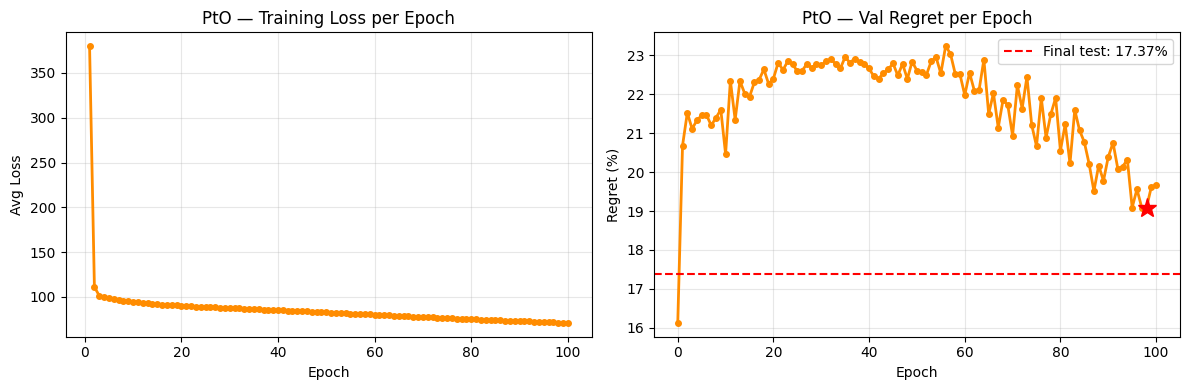

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_PtO.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 100
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_title("PtO — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_title("PtO — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/pto_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 148.1910915150      21.41%
     2 96.4615293373      21.22%
     3 93.3390027965      21.02%
     4 91.4620109453      20.28%
     5 90.3172560787      19.78%
     6 89.5045216146      19.71%
     7 88.7676116434      20.61%
     8 88.0071381149      19.70%
     9 87.2153404321      19.19%
    10 86.4076100045      19.66%
    11 85.6127976248      19.29%
    12 84.8629847771      19.53%
    13 84.1579582928      18.91%
    14 83.4987401962      18.23%
    15 82.8817305091      18.92%
    16 82.3214473050      18.30%
    17 81.7918199894      18.86%
    18 81.3003511529      18.93%
    19 80.8006615564      18.75%
    20 80.2955791463      18.93%
    21 79.7999299559      18.63%
    22 79.2995302115      18.44%
    23 78.8021250820      17.70%
    24 78.3019645351      18.66%
    25 77.8045663933      17.92%
    26 77.3217742505      18.03%
    27 76.8422377322      18.13%


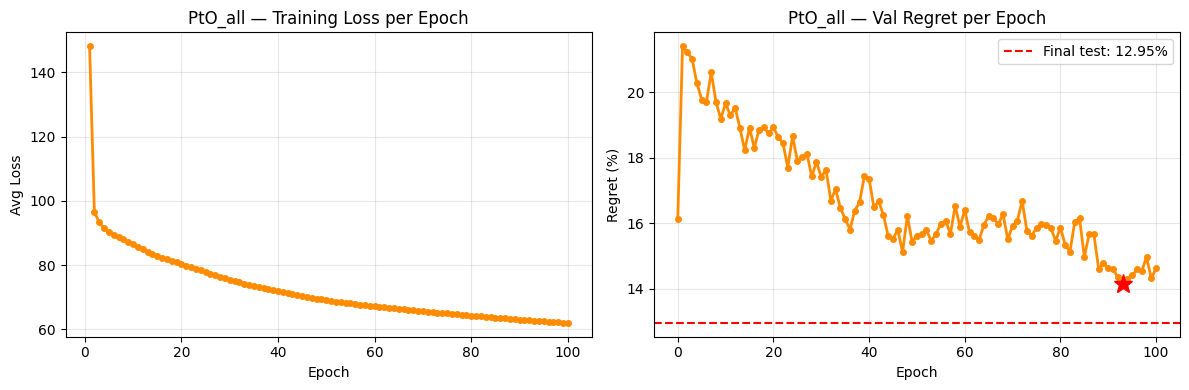

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_PtO_all.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 100
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_title("PtO_all — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_title("PtO_all — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/pto_curves_all.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 -37.6501715088      23.04%
     2 -54.9306379566      26.57%
     3 -47.6602143097      21.93%
     4 -57.1323149776      19.75%
     5 -90.0547511005      21.26%
     6 -85.6593813400      21.30%
     7 -105.1315216103      18.96%
     8 -164.5971917648      17.06%
     9 -72.8301022186      24.68%
    10 -149.2539943085      10.59%
    11 -18.7735436707       8.25%
    12 -799.8887344666      38.20%
    13 -818.2353630524      26.65%
    14 -1259.2462240601      68.97%
    15 -1919.0576353760      26.49%
    16 -2715.7060263672      26.99%
    17 -2416.1136270752      73.23%
    18 -3764.8410937500      66.58%
    19 -5078.0183603516      45.06%
    20 -7456.4626455078      32.26%

Best epoch: 11, best val regret: 8.25%
Final test regret: 5.8955%


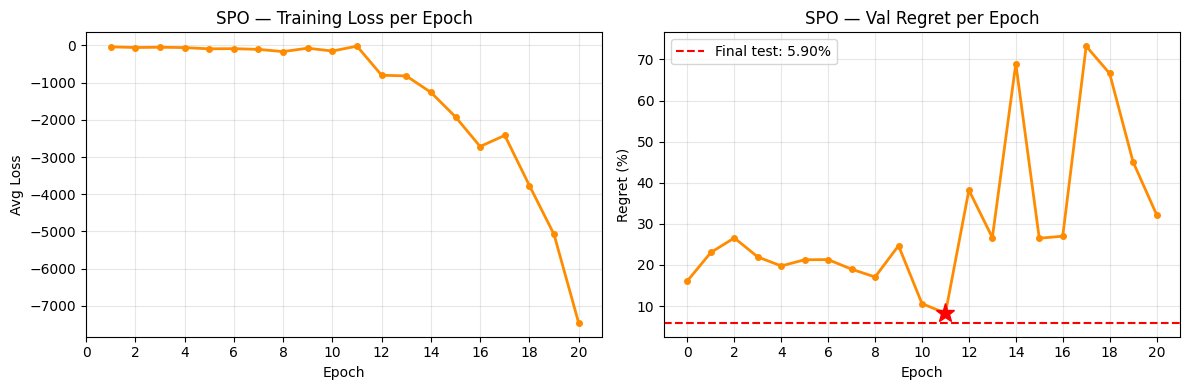

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_SPO.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("SPO — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("SPO — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/spo_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 -11.0411586990      21.68%
     2 -1.0765302753      16.49%
     3 -0.7493052731      21.64%
     4 -0.8661549473      15.60%
     5 -96.2971448631      18.75%
     6 -63.9273646054      28.75%
     7 -40.6179288635      24.52%
     8 -21.0379736938      26.08%
     9 -24.1908666573      32.50%
    10 -85.0460875566      20.51%
    11 -234.7105643699       6.85%
    12 -25.7333174577       6.63%
    13 -1.8598081662       6.17%
    14 -10.2574589844       6.17%
    15 -4.2087734375       6.17%
    16 0.0000000000       6.17%
    17 0.0000000000       6.17%
    18 0.0000000000       6.17%
    19 0.0000000000       6.17%
    20 0.0000000000       6.17%

Best epoch: 13, best val regret: 6.17%
Final test regret: 5.6841%


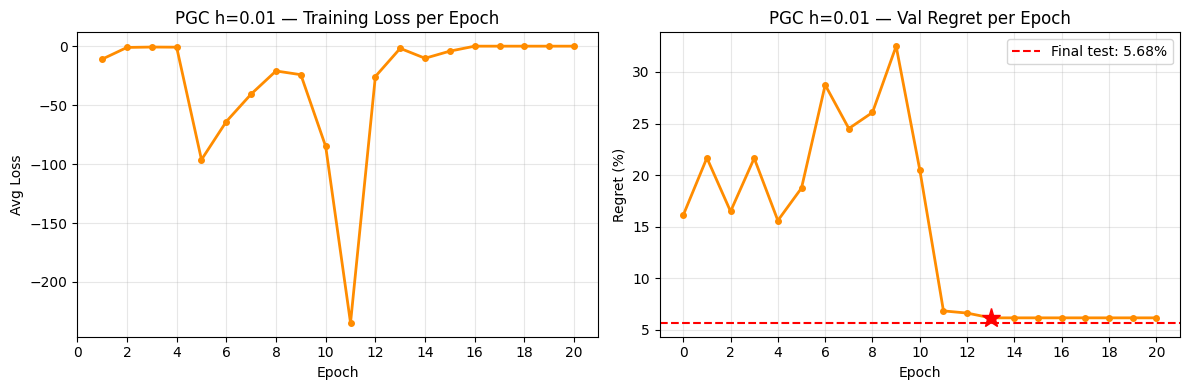

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_PGC.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PGC h=0.01 — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PGC h=0.01 — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/pgc_h001_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 -17.0625326004      20.60%
     2 -141.2465873146      20.66%
     3 -20.1868672638      44.27%
     4 -167.5650459368      23.10%
     5 -156.5014281977      18.22%
     6 -348.5619919335       7.93%
     7 -131.8703216207       5.59%
     8 -8.4173147504       5.49%
     9 -5.9034035378       5.49%
    10 0.0000004746       5.49%
    11 0.0000003929       5.49%
    12 0.0000008165       5.49%
    13 -0.0000322010       5.49%
    14 -0.0000969032       5.34%
    15 0.0000025946       5.34%
    16 0.0000023742       5.34%
    17 0.0000017048       5.34%
    18 0.0000016757       5.34%
    19 0.0000013533       5.34%
    20 0.0000010962       5.34%

Best epoch: 14, best val regret: 5.34%
Final test regret: 6.3332%


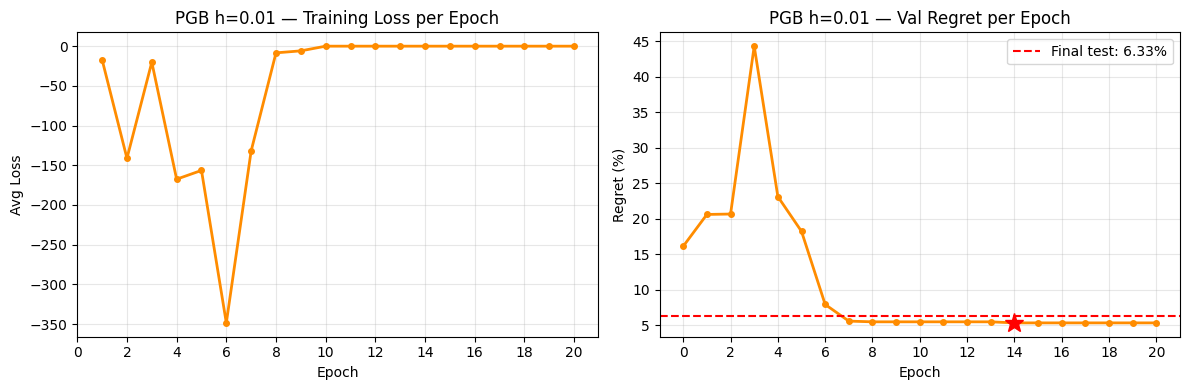

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_PGB.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PGB h=0.01 — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PGB h=0.01 — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/pgb_h001_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.04%
     1 0.3468899872      16.72%
     2 0.1628045099      18.88%
     3 0.0956847879      19.22%
     4 0.0306041539      15.22%
     5 0.0941968355      18.97%
     6 0.0779448872      18.36%
     7 0.0585693778      17.46%
     8 0.0390061201      17.73%
     9 0.0540785068      14.94%
    10 0.0072552947      18.35%
    11 0.0807290146      17.30%
    12 0.0077694351      15.76%
    13 0.0305765141      14.91%
    14 0.0082913541      17.43%
    15 0.0181492052      13.79%
    16 0.0262345300      18.36%
    17 0.0302433341      19.81%
    18 0.0209024880      19.47%
    19 0.0282199054      15.97%
    20 -0.0058772298      14.97%

Best epoch: 15, best val regret: 13.79%
Final test regret: 8.3290%


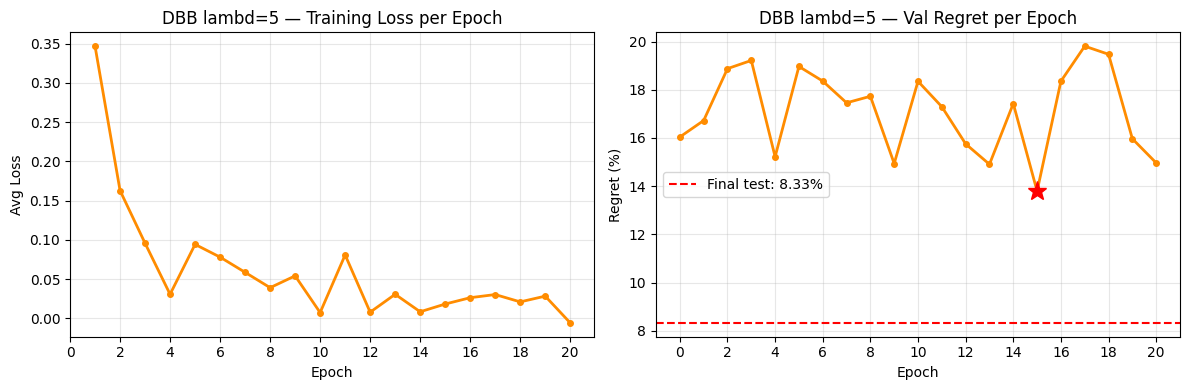

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_DBB.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("DBB lambd=5 — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("DBB lambd=5 — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/dbb_lambd5_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 73.8255448608       8.04%
     2 9.0203734436       7.57%
     3 80.5889783630       6.86%
     4 -18.2306321411       6.14%
     5 -169.0069474182       7.98%
     6 43.8155750122       7.74%
     7 33.6101956177       7.97%
     8 55.9939808960       8.89%
     9 -162.9201058960       6.77%
    10 -73.9751726074       8.02%
    11 -15.4728320313       6.86%
    12 172.0907858124       7.45%
    13 -3.2516561279       7.49%
    14 -133.4118443909       7.83%
    15 -44.0077249451       7.59%
    16 -31.3922855225       6.47%
    17 255.7996377563       7.16%
    18 -188.1642655334       6.50%
    19 -95.9497029419       7.19%
    20 94.5865796509       8.07%

Best epoch: 4, best val regret: 6.14%
Final test regret: 4.3979%


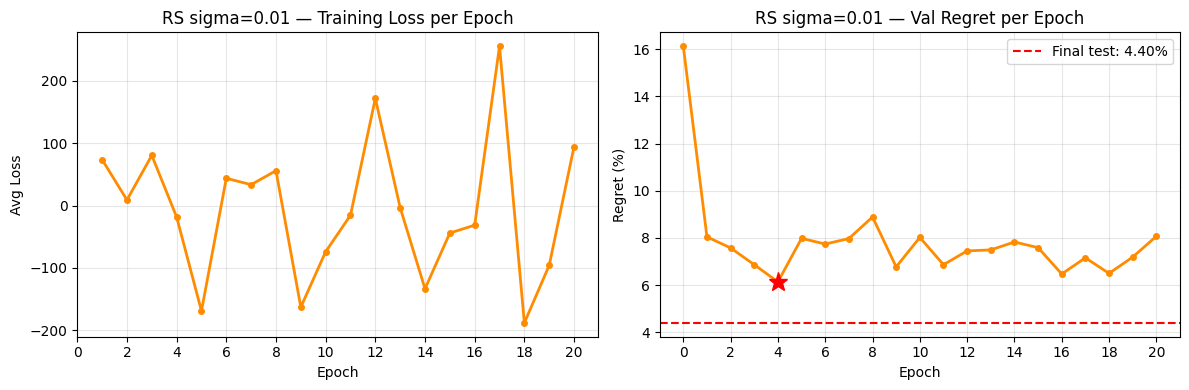

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_RS.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("RS sigma=0.01 — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("RS sigma=0.01 — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/rs_sigma001_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

Epoch  Avg loss        Regret(160) 
------------------------------------
0      —                    16.13%
     1 -0.2208924028      21.49%
     2 -8.4559996471      47.68%
     3 -48.8217802582      33.47%
     4 -131.7460291443      59.42%
     5 -287.9926718750      12.32%
     6 -603.1588432617      37.78%
     7 -1070.0731850586      13.93%
     8 -1468.5756264648      10.32%
     9 -2142.7049082031      23.92%
    10 -3394.6107519531      91.18%
    11 -4207.6888759766     115.20%
    12 -5806.2044570313      30.74%
    13 -7787.5426855469      82.28%
    14 -9769.2844785156      20.77%
    15 -11197.4589140625      25.85%
    16 -12484.0030058594      94.80%
    17 -16566.7906015625     138.98%
    18 -18598.1559360352      42.24%
    19 -21093.6711777344     124.31%
    20 -20800.6345039063      56.40%

Best epoch: 8, best val regret: 10.32%
Final test regret: 9.7735%


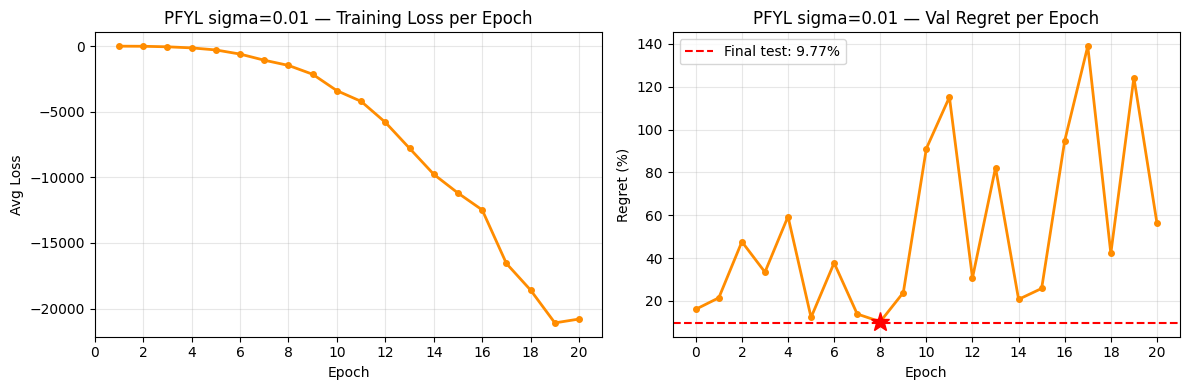

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
log_path = f"{PROJECT}/saved_models/amazon_regret_log_PFYL.json"

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']  # length = n_epochs + 1 (includes epoch 0)

n_epochs  = 20
n_batches = len(loss_log) // n_epochs

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s} {'Avg loss':15s} {'Regret(160)':12s}")
print("-" * 36)
print(f"{'0':6s} {'—':15s} {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    print(f"{epoch+1:6d} {epoch_avg_loss[epoch]:.10f} "
          f"{regret_log[epoch+1]*100:10.2f}%")

print(f"\nBest epoch: {d['best_epoch']}, "
      f"best val regret: {d['best_regret']*100:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_epochs+1), epoch_avg_loss,
        color='darkorange', lw=2, marker='o', markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Loss")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PFYL sigma=0.01 — Training Loss per Epoch")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4)
ax.axhline(d['true_regret']*100, color='red', linestyle='--',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Regret (%)")
ax.set_xticks(range(0, 21, 2))  # ticks at 0, 2, ..., 20
ax.set_title("PFYL sigma=0.01 — Val Regret per Epoch")
ax.legend(); ax.grid(alpha=0.3)

best_ep  = d['best_epoch']
best_val = d['best_regret'] * 100
ax.plot(best_ep, best_val,
         marker='*', markersize=14,
         color='red', zorder=5,
         label=f'Best={best_val:.2f}%')


plt.tight_layout()
plt.savefig(f"{PROJECT}/figs/pfyl_sigma001_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch   Avg loss            Regret(160) 
------------------------------------------
0       —                        16.13%
     1          148.191092       21.41%
     2           96.461529       21.22%
     3           93.339003       21.02%
     4           91.462011       20.28%
     5           90.317256       19.78%
     6           89.504522       19.71%
     7           88.767612       20.61%
     8           88.007138       19.70%
     9           87.215340       19.19%
    10           86.407610       19.66%
    11           85.612798       19.29%
    12           84.862985       19.53%
    13           84.157958       18.91%
    14           83.498740       18.23%
    15           82.881731       18.92%
    16           82.321447       18.30%
    17           81.791820       18.86%
    18           81.300351       18.93%
    19           80.800662       18.75%
    20           80.295579       18.93%
    21           79.799930       18.63%
    22           79.299530       18.

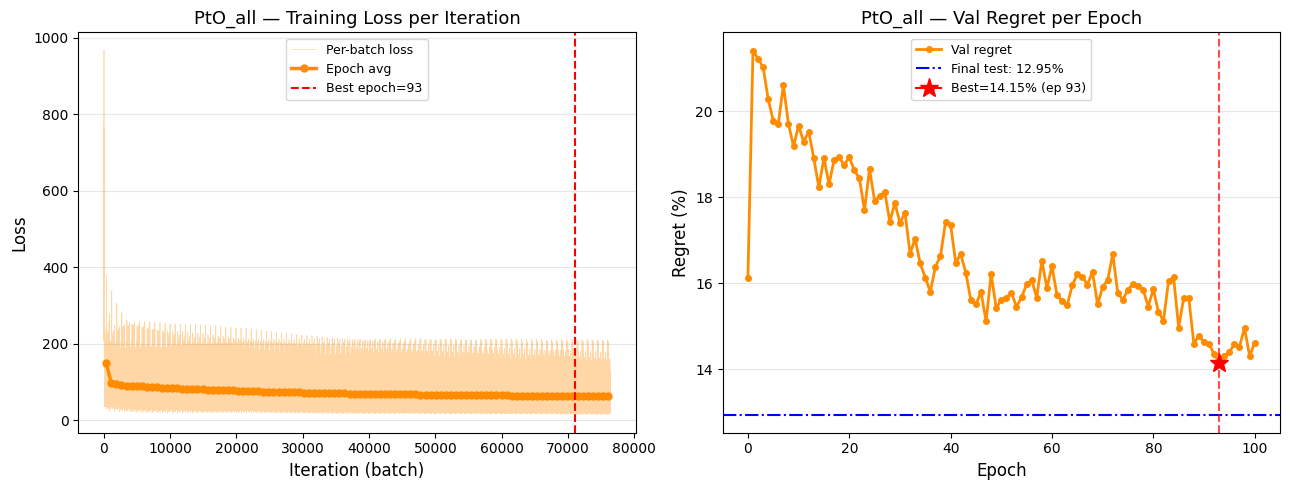

Saved: /content/drive/MyDrive/CSCI 619 project_2/figs_batch/PtO_all_curves.pdf


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

PROJECT  = "/content/drive/MyDrive/CSCI 619 project_2"
METHOD   = "PtO"   # ← change this for each method
LOG_DIR  = f"{PROJECT}/saved_models"  # ← change folder as needed
log_path = f"{LOG_DIR}/amazon_regret_log_{METHOD}_all.json"

os.makedirs(f"{PROJECT}/figs_batch", exist_ok=True)

with open(log_path) as f:
    d = json.load(f)

loss_log   = d['loss_log']
regret_log = d['regret_log']   # length = n_epochs + 1 (epoch 0 included)
n_epochs   = len(regret_log) - 1
n_batches  = len(loss_log) // n_epochs
best_ep    = d['best_epoch']
best_val   = d['best_regret'] * 100

# Per-epoch average loss
epoch_avg_loss = [np.mean(loss_log[e*n_batches:(e+1)*n_batches])
                  for e in range(n_epochs)]

# Print table
print(f"{'Epoch':6s}  {'Avg loss':18s}  {'Regret(160)':12s}")
print("-" * 42)
print(f"{'0':6s}  {'—':18s}  {regret_log[0]*100:10.2f}%")
for epoch in range(n_epochs):
    marker = " ← best" if (epoch + 1) == best_ep else ""
    print(f"{epoch+1:6d}  {epoch_avg_loss[epoch]:18.6f}  "
          f"{regret_log[epoch+1]*100:10.2f}%{marker}")

print(f"\nBest epoch: {best_ep},  "
      f"best val regret: {best_val:.2f}%")
print(f"Final test regret: {d['true_regret']*100:.4f}%")

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: loss per iteration ──────────────────────────────────────────
ax = axes[0]

# Light background: per-iteration loss
ax.plot(range(1, len(loss_log)+1), loss_log,
        color='darkorange', lw=0.5, alpha=0.35,
        label='Per-batch loss')

# Bold overlay: epoch average
epoch_centers = [e*n_batches + n_batches//2 for e in range(n_epochs)]
ax.plot(epoch_centers, epoch_avg_loss,
        color='darkorange', lw=2.5, marker='o',
        markersize=5, label='Epoch avg')

# Vertical line at best epoch
ax.axvline(x=best_ep * n_batches, color='red',
           linestyle='--', lw=1.5,
           label=f'Best epoch={best_ep}')

ax.set_xlabel("Iteration (batch)", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"{METHOD}_all — Training Loss per Iteration", fontsize=13)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Right: val regret per epoch ───────────────────────────────────────
ax = axes[1]

ax.plot(range(0, n_epochs+1), [r*100 for r in regret_log],
        color='darkorange', lw=2, marker='o', markersize=4,
        label='Val regret')

# Horizontal line: final test regret
ax.axhline(d['true_regret']*100, color='blue', linestyle='-.',
           lw=1.5, label=f"Final test: {d['true_regret']*100:.2f}%")

# Vertical line at best epoch
ax.axvline(x=best_ep, color='red', linestyle='--',
           lw=1.5, alpha=0.7)

# Star at best epoch
ax.plot(best_ep, best_val,
        marker='*', markersize=14,
        color='red', zorder=5,
        label=f'Best={best_val:.2f}% (ep {best_ep})')

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Regret (%)", fontsize=12)
# ax.set_xticks(range(0, n_epochs+1, 2)) # only for DFL methods
ax.set_title(f"{METHOD}_all — Val Regret per Epoch", fontsize=13)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_path = f"{PROJECT}/figs_batch/{METHOD}_all_curves.pdf"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

data = {
    'Method':             ['PtO',  'DBB',  'RS',   'PGB',  'PGC',  'SPO+', 'PFYL'],
    'Hyperparam':         ['—',    'λ=0.5','σ=0.1','h=0.01','h=0.01','—',  'σ=0.1'],
    'Best val regret':    ['19.09%','13.79%','6.14%','5.34%','6.17%','8.25%','10.32%'],
    'Best epoch':         [98,      15,       4,      14,     13,     11,      8],
    'Final test regret':  ['17.37%','8.33%','4.40%','6.33%','5.68%','5.90%','9.77%'],
    'LKH-3 calls/epoch':  [0,      2000,   3000,   2000,   2000,   1000,   3000],
    'Time/epoch':         ['~2.7s','~36min','~53min','~36min','~36min','~18min','~53min'],
    'Total time':         ['~4.5h(100ep)','~12h','~18h','~12h','~12h','~6h','~18h'],
}

df = pd.DataFrame(data).set_index('Method')

styled = df.style \
    .highlight_min(subset=['Final test regret'],
                   color='lightgreen') \
    .set_caption(
        "Table 2 — Final training results for all methods on Amazon FSTSP (n=4 customers). "
        "All DFL methods use η=5×10⁻⁴, 1,000 training instances, 160 validation and test instances. "
        "PtO uses η=5×10⁻⁴, 1,000 training instances, 100 epochs.") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '12px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center')]},
    ])

display(styled)

,Hyperparam,Best val regret,Best epoch,Final test regret,LKH-3 calls/epoch,Time/epoch,Total time
Method,,,,,,,
PtO,—,19.09%,98,17.37%,0,~2.7s,~4.5h(100ep)
DBB,λ=0.5,13.79%,15,8.33%,2000,~36min,~12h
RS,σ=0.1,6.14%,4,4.40%,3000,~53min,~18h
PGB,h=0.01,5.34%,14,6.33%,2000,~36min,~12h
PGC,h=0.01,6.17%,13,5.68%,2000,~36min,~12h
SPO+,—,8.25%,11,5.90%,1000,~18min,~6h
PFYL,σ=0.1,10.32%,8,9.77%,3000,~53min,~18h


Loaded DBB: final test = 8.33%
Loaded RS: final test = 4.40%
Loaded PGB: final test = 6.33%
Loaded PGC: final test = 5.68%
Loaded SPO: final test = 5.90%
Loaded PFYL: final test = 9.77%


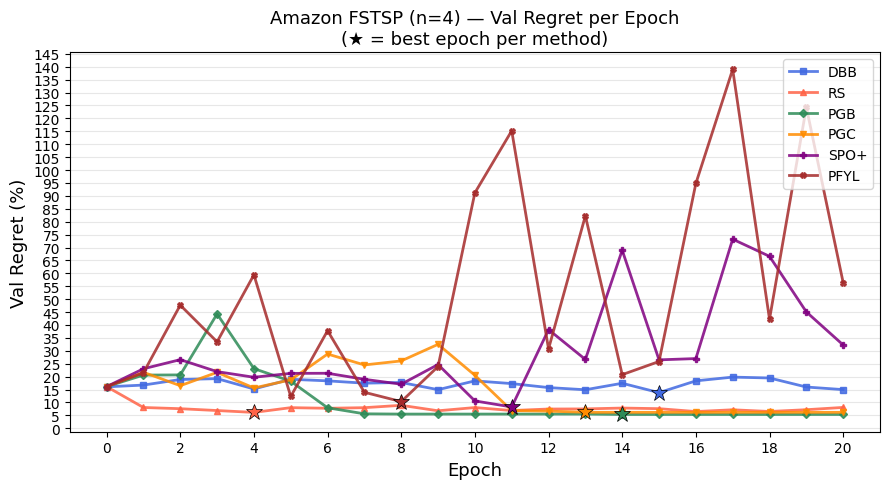

Saved: all_learning_curves.pdf


In [ ]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

PROJECT  = "/content/drive/MyDrive/CSCI 619 project_2"
os.makedirs(f"{PROJECT}/figs_all", exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────
# Figure 2: DFL methods only
methods = ['DBB', 'RS', 'PGB', 'PGC', 'SPO', 'PFYL']
labels  = ['DBB', 'RS', 'PGB', 'PGC', 'SPO+', 'PFYL']
colors  = ['royalblue', 'tomato', 'seagreen',
               'darkorange', 'purple', 'brown']
markers = ['s', '^', 'D', 'v', 'P', 'X']

# Folder containing all JSON logs (lr=5e-4, 1000 inst)
LOG_DIR = f"{PROJECT}/saved_models"

results = {}
for m in methods:
    path = f"{LOG_DIR}/amazon_regret_log_{m}.json"
    try:
        with open(path) as f:
            results[m] = json.load(f)
        print(f"Loaded {m}: final test = {results[m]['true_regret']*100:.2f}%")
    except:
        print(f"Missing: {m}")

# ── Figure 2: Learning curves (val regret per epoch, all methods) ─────
fig, ax = plt.subplots(figsize=(9, 5))

for m, label, col, mk in zip(methods, labels, colors, markers):
    if m not in results: continue
    regret = [r*100 for r in results[m]['regret_log']]
    n_ep   = len(regret) - 1
    best_ep  = results[m]['best_epoch']
    best_val = results[m]['best_regret'] * 100

    ax.plot(range(0, n_ep+1), regret,
            color=col, lw=2, alpha=0.85,
            marker=mk, markersize=4,
            label=label)

    # Star at best epoch
    ax.plot(best_ep, best_val,
            marker='*', markersize=12,
            color=col, zorder=5,
            markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Val Regret (%)", fontsize=13)
ax.set_title("Amazon FSTSP (n=4) — Val Regret per Epoch\n"
             "(★ = best epoch per method)", fontsize=13)
ax.set_xticks(range(0, 21, 2))
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT}/figs_batch/all_learning_curves.pdf",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_learning_curves.pdf")


In [ ]:
"""
generate_predictions.py
Run in Colab to generate predicted vs real travel time CSV files.

Usage:
    # In Colab cell:
    exec(open('generate_predictions.py').read())
"""

import torch, pickle, numpy as np, pandas as pd, os

# ── Paths ─────────────────────────────────────────────────────────────
PROJECT     = "/content/drive/MyDrive/CSCI 619 project_2"
MODEL_DIR   = f"{PROJECT}/saved_models"
DATASET_DIR = f"{PROJECT}/amazon_instances/dataset"
OUTPUT_DIR  = f"{PROJECT}/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

n_orig = 6
N_INSTANCES = 10   # number of test instances to export

# ── Define classes ────────────────────────────────────────────────────
class g_theta(torch.nn.Module):
    def __init__(self, dim_s=16, dim_t=72, hidden=128, depth=2):
        super().__init__()
        dims=[dim_s]+[hidden]*depth+[dim_t]
        layers=[]
        for i in range(len(dims)-1):
            layers.append(torch.nn.Linear(dims[i],dims[i+1]))
            if i<len(dims)-2: layers.append(torch.nn.ReLU())
        layers.append(torch.nn.Softplus())
        self.net=torch.nn.Sequential(*layers)
    def forward(self, s): return self.net(s)

class PrecomputedOptDataset(torch.utils.data.Dataset):
    def __init__(self, S_hat, W_hat, z_hat_oracle, z_oracle):
        self.S_hat        = torch.FloatTensor(S_hat)
        self.W_hat        = torch.FloatTensor(W_hat)
        self.z_hat_oracle = torch.FloatTensor(z_hat_oracle)
        self.z_oracle     = torch.FloatTensor(z_oracle).view(-1,1)
    def __len__(self): return len(self.S_hat)
    def __getitem__(self, idx):
        return (self.S_hat[idx], self.W_hat[idx],
                self.z_hat_oracle[idx], self.z_oracle[idx])

# ── Load oracle ───────────────────────────────────────────────────────
with open(f"{DATASET_DIR}/oracle.pkl", 'rb') as f:
    _, _, dataset_test = pickle.load(f)
print(f"Test set: {len(dataset_test)} instances")

# ── Load predictors ───────────────────────────────────────────────────
methods = ['PtO', 'DBB', 'RS', 'PGB', 'PGC', 'SPO', 'PFYL']
predictors = {}
for m in methods:
    try:
        pred = g_theta()
        pred.load_state_dict(torch.load(f"{MODEL_DIR}/amazon_predictor_{m}.pt",
                                         map_location='cpu'))
        pred.eval()
        predictors[m] = pred
        print(f"Loaded: {m}")
    except:
        print(f"Skipped: {m}")

# ── Generate predictions for N_INSTANCES test instances ───────────────
# File 1: truck travel times comparison (all pairs, all methods)
rows = []
for inst_idx in range(N_INSTANCES):
    s_hat, w_hat, zh, z_oracle = dataset_test[inst_idx]
    w_np = w_hat.numpy()
    tau_truck_real = w_np[:n_orig**2].reshape(n_orig, n_orig)

    for i in range(n_orig):
        for j in range(n_orig):
            if i == j: continue
            row = {
                'instance':     inst_idx,
                'oracle_cost':  float(z_oracle),
                'from_node':    i,
                'to_node':      j,
                'w_hat_truck':  tau_truck_real[i, j],   # real travel time
            }
            for m, pred in predictors.items():
                with torch.no_grad():
                    t_np = pred(s_hat.unsqueeze(0)).squeeze().numpy()
                tau_truck_pred = t_np[:n_orig**2].reshape(n_orig, n_orig)
                row[f't_hat_{m}'] = tau_truck_pred[i, j]
            rows.append(row)

df_truck = pd.DataFrame(rows)
path1 = f"{OUTPUT_DIR}/truck_time_predictions.csv"
df_truck.to_csv(path1, index=False)
print(f"\nSaved: {path1}")
print(f"  Shape: {df_truck.shape}")
print(df_truck[['from_node','to_node','w_hat_truck',
                 't_hat_PtO','t_hat_DBB','t_hat_RS',
                 't_hat_PGB','t_hat_PGC',
                 't_hat_SPO','t_hat_PFYL']].head(10).to_string())

# File 2: summary statistics per method per instance
rows2 = []
for inst_idx in range(N_INSTANCES):
    s_hat, w_hat, zh, z_oracle = dataset_test[inst_idx]
    w_np = w_hat.numpy()
    tau_truck_real = w_np[:n_orig**2].reshape(n_orig, n_orig)
    tau_drone_real = w_np[n_orig**2:].reshape(n_orig, n_orig)
    mask_truck = tau_truck_real > 0

    for m, pred in predictors.items():
        with torch.no_grad():
            t_np = pred(s_hat.unsqueeze(0)).squeeze().numpy()
        tau_truck_pred = t_np[:n_orig**2].reshape(n_orig, n_orig)
        corr = np.corrcoef(tau_truck_real[mask_truck],
                            tau_truck_pred[mask_truck])[0,1]
        mape = np.abs((tau_truck_pred[mask_truck] - tau_truck_real[mask_truck]) /
                       (tau_truck_real[mask_truck] + 1e-8)).mean() * 100
        rows2.append({
            'instance':      inst_idx,
            'method':        m,
            'oracle_cost':   float(z_oracle),
            'real_mean':     tau_truck_real[mask_truck].mean(),
            'pred_mean':     tau_truck_pred[mask_truck].mean(),
            'real_std':      tau_truck_real[mask_truck].std(),
            'pred_std':      tau_truck_pred[mask_truck].std(),
            'correlation':   corr,
            'mape_pct':      mape,
        })

df_summary = pd.DataFrame(rows2)
path2 = f"{OUTPUT_DIR}/prediction_summary.csv"
df_summary.to_csv(path2, index=False)
print(f"\nSaved: {path2}")
print(df_summary.groupby('method')[['correlation','mape_pct']].mean().round(4))




# Add MAE to summary
rows2_updated = []
for inst_idx in range(N_INSTANCES):
    s_hat, w_hat, zh, z_oracle = dataset_test[inst_idx]
    w_np = w_hat.numpy()
    tau_truck_real = w_np[:n_orig**2].reshape(n_orig, n_orig)
    mask_truck = tau_truck_real > 0

    for m, pred in predictors.items():
        with torch.no_grad():
            t_np = pred(s_hat.unsqueeze(0)).squeeze().numpy()
        tau_truck_pred = t_np[:n_orig**2].reshape(n_orig, n_orig)
        corr = np.corrcoef(tau_truck_real[mask_truck],
                            tau_truck_pred[mask_truck])[0,1]
        mape = np.abs((tau_truck_pred[mask_truck] - tau_truck_real[mask_truck]) /
                       (tau_truck_real[mask_truck] + 1e-8)).mean() * 100
        mae  = np.abs(tau_truck_pred[mask_truck] -
                       tau_truck_real[mask_truck]).mean()
        rows2_updated.append({
            'method': m, 'correlation': corr,
            'mape_pct': mape, 'mae_min': mae
        })

df2 = pd.DataFrame(rows2_updated)
print(df2.groupby('method')[['correlation','mape_pct','mae_min']].mean().round(3))

Test set: 1526 instances
Loaded: PtO
Loaded: DBB
Loaded: RS
Loaded: PGB
Loaded: PGC
Loaded: SPO
Loaded: PFYL

Saved: /content/drive/MyDrive/CSCI 619 project_2/predictions/truck_time_predictions.csv
  Shape: (300, 12)
   from_node  to_node  w_hat_truck  t_hat_PtO  t_hat_DBB  t_hat_RS  t_hat_PGB  t_hat_PGC   t_hat_SPO    t_hat_PFYL
0          0        1    32.478600  48.231674   0.671598  0.821930  22.419012  16.890324  337.431671  9.000826e+02
1          0        2    42.172028  49.298565   0.680917  1.081432  23.956804   9.021411  369.954315  8.989285e+02
2          0        3    40.523712  48.620781   0.670090  0.529435  40.851154  15.019772  403.275543  8.775445e+02
3          0        4    42.136349  47.586006   0.657515  0.811143  31.872133  13.908577  361.350189  8.390163e+02
4          0        5     0.000000   0.000001   0.578736  0.356263   0.030232   0.195762    0.000012  6.455736e-08
5          1        0    50.244286  48.653275   0.732254  0.513070  15.616717   0.945433  398

In [ ]:
import pandas as pd
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────
data = {
    'Method':      ['PtO',   'DBB',   'RS',    'PGB',   'PGC',   'SPO+',  'PFYL'],
    'Correlation': [ 0.938,  -0.496,   0.144,   0.206,   0.303,   0.306,  -0.524],
    'MAE (min)':   [ 7.8,    20.5,    20.5,    16.9,    17.8,   133.9,   599.6],
    'MAPE (%)':    [ 80.6,   87.4,    87.2,   295.5,   179.2,  2857.8, 24603.0],
    'Test Regret (%)': [17.37, 8.33,  4.40,    6.33,    5.68,    5.90,    9.77],
}

df = pd.DataFrame(data).set_index('Method')

# ── Formatting helpers ────────────────────────────────────────────────
def fmt_corr(v):
    s = f'{v:.3f}'
    return f'**{s}**' if v == df['Correlation'].max() else s

def fmt_mae(v):
    s = f'{v:.1f}'
    return f'**{s}**' if v == df['MAE (min)'].min() else s

def fmt_mape(v):
    if v > 1000:
        return f'{v:.0f}†'
    s = f'{v:.1f}'
    return f'**{s}**' if v == df['MAPE (%)'].min() else s

def fmt_regret(v):
    s = f'{v:.2f}%'
    return f'**{s}**' if v == df['Test Regret (%)'].min() else s

# ── Print styled table ────────────────────────────────────────────────
print("Table 4 — Prediction Accuracy vs Decision Quality")
print("=" * 75)
print(f"{'Method':8s}  {'Corr (↑)':>10s}  {'MAE min (↓)':>12s}  "
      f"{'MAPE% (↓)':>12s}  {'Regret% (↓)':>12s}")
print("-" * 75)

for method, row in df.iterrows():
    sep = "─" * 75 if method == 'DBB' else ""
    if sep: print(sep)  # separator between PtO and DFL methods
    corr   = fmt_corr(row['Correlation'])
    mae    = fmt_mae(row['MAE (min)'])
    mape   = fmt_mape(row['MAPE (%)'])
    regret = fmt_regret(row['Test Regret (%)'])
    print(f"{method:8s}  {corr:>10s}  {mae:>12s}  {mape:>12s}  {regret:>12s}")

print("=" * 75)
print("† Large values reflect weight divergence; best epoch saved before divergence.")
print("** Bold = best value in column")
print("\n↑ higher is better   ↓ lower is better")

# ── Also export as CSV ────────────────────────────────────────────────
PROJECT = "/content/drive/MyDrive/CSCI 619 project_2"
df.to_csv(f"{PROJECT}/predictions/table4_prediction_accuracy.csv")
print(f"\nSaved CSV: {PROJECT}/predictions/table4_prediction_accuracy.csv")

# ── Styled pandas display ─────────────────────────────────────────────
try:
    styled = df.style\
        .highlight_max(subset=['Correlation'], color='lightgreen')\
        .highlight_min(subset=['MAE (min)', 'MAPE (%)', 'Test Regret (%)'],
                       color='lightgreen')\
        .format({
            'Correlation':     '{:.3f}',
            'MAE (min)':       '{:.1f}',
            'MAPE (%)':        '{:.1f}',
            'Test Regret (%)': '{:.2f}%',
        })
    display(styled)
except:
    print(df.round(3))

Table 4 — Prediction Accuracy vs Decision Quality
Method      Corr (↑)   MAE min (↓)     MAPE% (↓)   Regret% (↓)
---------------------------------------------------------------------------
PtO        **0.938**       **7.8**      **80.6**        17.37%
───────────────────────────────────────────────────────────────────────────
DBB           -0.496          20.5          87.4         8.33%
RS             0.144          20.5          87.2     **4.40%**
PGB            0.206          16.9         295.5         6.33%
PGC            0.303          17.8         179.2         5.68%
SPO+           0.306         133.9         2858†         5.90%
PFYL          -0.524         599.6        24603†         9.77%
† Large values reflect weight divergence; best epoch saved before divergence.
** Bold = best value in column

↑ higher is better   ↓ lower is better

Saved CSV: /content/drive/MyDrive/CSCI 619 project_2/predictions/table4_prediction_accuracy.csv


,Correlation,MAE (min),MAPE (%),Test Regret (%)
Method,,,,
PtO,0.938,7.8,80.6,17.37%
DBB,-0.496,20.5,87.4,8.33%
RS,0.144,20.5,87.2,4.40%
PGB,0.206,16.9,295.5,6.33%
PGC,0.303,17.8,179.2,5.68%
SPO+,0.306,133.9,2857.8,5.90%
PFYL,-0.524,599.6,24603.0,9.77%
